# 🛡️ CNN Phân Loại Mã Độc — Pure INT8 QAT

**Kiến trúc:** CNN (8×32×1 input)  
**Quantization:** Quantization-Aware Training — Pure INT8 (Chi-You style)  
**Mục tiêu:** Xuất weights INT8 thuần túy để nạp thẳng lên phần cứng (FPGA/ASIC)  

---

### Luồng xử lý
```
Dataset ảnh PNG
    ↓ (chỉ lần đầu — lần sau load cache)
Tiền xử lý → cache dataset.npz  
    ↓
Train float32  (10 epochs)
    ↓
QAT fine-tune  (5 epochs) — weights/activations bị ép vào lưới INT8
    ↓
Export: weights INT8 + shift_params → JSON / Excel
```

### Quy ước INT8 trong notebook này
| Vị trí | Range | Ghi chú |
|---|---|---|
| Weights (Conv, Dense) | [-127, 127] | Signed INT8 |
| Activations (ReLU) | [0, 127] | Unsigned INT8 |
| Accumulator MAC | INT32 | Tránh overflow |
| Output Dense(2) | INT32 thô | So sánh trực tiếp, không cần softmax |

> ⚠️ Bật GPU trước khi chạy: `Runtime → Change runtime type → T4 GPU`

## 📦 1. Cài Đặt Thư Viện

In [1]:
!pip install -q openpyxl
print('✅ Cài đặt xong!')

✅ Cài đặt xong!


## ☁️ 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mount thành công!')

Mounted at /content/drive
✅ Google Drive mount thành công!


## ⚙️ 3. Cấu Hình Tham Số

In [3]:
# ================================================================
#  THAY ĐỔI CÁC GIÁ TRỊ NÀY TRƯỚC KHI CHẠY
# ================================================================

# Thư mục chứa dataset ảnh PNG
# Cấu trúc:
#   malimg/
#     benign/          ← file .png benign
#     Allaple.A/       ← file .png malware family
#     Allaple.L/
#     ...
# Thêm biến global điều khiển — đặt ở cell config hoặc cell imports
QAT_ACTIVE = False  # False = train float32 bình thường, True = bật fake-quant

DATASET_PATH = '/content/drive/MyDrive/CNX/malimg'

# Thư mục lưu toàn bộ kết quả (model, weights, cache, biểu đồ...)
OUTPUT_DIR   = '/content/drive/MyDrive/CNX'

# Random seed — đồng bộ hóa toàn bộ pipeline
RANDOM_SEED  = 42

# ── Siêu tham số huấn luyện ──────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS_F32   = 10    # Giai đoạn 1: Train float32 bình thường
EPOCHS_QAT   = 10     # Giai đoạn 2: QAT fine-tune
TEST_SPLIT   = 0.3

# ── Tham số Quantization ─────────────────────────────────────────
# SHIFT_BITS: số bit dịch phải sau MAC (INT32 → INT8)
# Công thức tham khảo: SHIFT_BITS = 7 cho mạng 2 conv layer
# Tăng lên 8 nếu thấy activation bị bão hòa (toàn 127)
SHIFT_BITS   = 7

# ── Đường dẫn cache ──────────────────────────────────────────────
import os
CACHE_PATH   = os.path.join(OUTPUT_DIR, 'cache', 'dataset.npz')

# ================================================================
print('=' * 50)
print(f'📂 Dataset     : {DATASET_PATH}')
print(f'📁 Output      : {OUTPUT_DIR}')
print(f'💾 Cache       : {CACHE_PATH}')
print(f'🎲 Seed        : {RANDOM_SEED}')
print(f'🔁 Epochs F32  : {EPOCHS_F32}')
print(f'🔁 Epochs QAT  : {EPOCHS_QAT}')
print(f'⚙️  Shift bits  : {SHIFT_BITS}')
print('=' * 50)

📂 Dataset     : /content/drive/MyDrive/CNX/malimg
📁 Output      : /content/drive/MyDrive/CNX
💾 Cache       : /content/drive/MyDrive/CNX/cache/dataset.npz
🎲 Seed        : 42
🔁 Epochs F32  : 10
🔁 Epochs QAT  : 10
⚙️  Shift bits  : 7


## 📚 4. Import Thư Viện

In [4]:
import os, glob, random, time, json
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, Layer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

# Tạo thư mục cần thiết
for d in [OUTPUT_DIR,
          os.path.join(OUTPUT_DIR, 'cache'),
          os.path.join(OUTPUT_DIR, 'dat'),
          os.path.join(OUTPUT_DIR, 'hardware')]:
    os.makedirs(d, exist_ok=True)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📂 5. Đọc & Tiền Xử Lý Dữ Liệu (Có Cache)

**Logic cache:**
- Nếu `dataset.npz` đã tồn tại → load thẳng, **bỏ qua toàn bộ bước đọc ảnh**
- Nếu chưa có → đọc ảnh, cân bằng, chuẩn hóa, **lưu cache** để lần sau dùng lại

In [5]:
if os.path.exists(CACHE_PATH):
    # ── LOAD CACHE ───────────────────────────────────────────────
    print(f'✅ Tìm thấy cache tại: {CACHE_PATH}')
    print('   Đang load cache — bỏ qua bước đọc ảnh...')
    cache = np.load(CACHE_PATH)
    X_train = cache['X_train']
    X_test  = cache['X_test']
    y_train = cache['y_train']
    y_test  = cache['y_test']
    print(f'   X_train : {X_train.shape} | y_train : {y_train.shape}')
    print(f'   X_test  : {X_test.shape}  | y_test  : {y_test.shape}')
    print('✅ Load cache hoàn tất!')

else:
    # ── BUILD FROM SCRATCH ───────────────────────────────────────
    print('⚠️  Không tìm thấy cache — Đang đọc ảnh từ dataset...')

    if not os.path.exists(DATASET_PATH):
        raise FileNotFoundError(f'❌ Không tìm thấy dataset tại: {DATASET_PATH}')

    benign_paths  = []
    malware_paths = []

    for fam_name in os.listdir(DATASET_PATH):
        fam_dir = os.path.join(DATASET_PATH, fam_name)
        if not os.path.isdir(fam_dir):
            continue
        imgs = glob.glob(os.path.join(fam_dir, '*.png'))
        if fam_name.lower() == 'benign':
            benign_paths.extend(imgs)
        else:
            malware_paths.extend(imgs)

    # Cân bằng: Malware = 2 × Benign
    num_benign     = len(benign_paths)
    target_malware = num_benign * 2
    print(f'   Benign gốc  : {num_benign}')
    print(f'   Malware gốc : {len(malware_paths)}')

    if len(malware_paths) > target_malware:
        random.seed(RANDOM_SEED)
        malware_paths = random.sample(malware_paths, target_malware)
    print(f'   Malware sau downsampling: {len(malware_paths)}')

    # Đọc ảnh → resize 8×32 → float32 [0,1]
    X, y = [], []
    print('   Đang đọc ảnh Benign...')
    for p in benign_paths:
        with Image.open(p) as im:
            X.append(np.array(im.resize((8, 32), Image.Resampling.LANCZOS)))
            y.append([1, 0])

    print('   Đang đọc ảnh Malware...')
    for p in malware_paths:
        with Image.open(p) as im:
            X.append(np.array(im.resize((8, 32), Image.Resampling.LANCZOS)))
            y.append([0, 1])

    X = np.array(X).astype('float32') / 255.0
    y = np.array(y)
    total = len(X)
    X = X.reshape(total, 8, 32, 1)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SPLIT, random_state=RANDOM_SEED
    )

    # Lưu cache
    np.savez_compressed(CACHE_PATH,
                        X_train=X_train, X_test=X_test,
                        y_train=y_train, y_test=y_test)
    print(f'✅ Đã lưu cache tại: {CACHE_PATH}')

# Thống kê phân phối
print('\n' + '-'*45)
print('THỐNG KÊ PHÂN PHỐI DỮ LIỆU')
print('-'*45)
print(f'TỔNG  : Benign={int(np.sum(np.concatenate([y_train,y_test])[:,0]))} | Malware={int(np.sum(np.concatenate([y_train,y_test])[:,1]))}')
print(f'TRAIN : Benign={int(np.sum(y_train[:,0]))} | Malware={int(np.sum(y_train[:,1]))}')
print(f'TEST  : Benign={int(np.sum(y_test[:,0]))}  | Malware={int(np.sum(y_test[:,1]))}')
print('-'*45)

✅ Tìm thấy cache tại: /content/drive/MyDrive/CNX/cache/dataset.npz
   Đang load cache — bỏ qua bước đọc ảnh...
   X_train : (2062, 8, 32, 1) | y_train : (2062, 2)
   X_test  : (884, 8, 32, 1)  | y_test  : (884, 2)
✅ Load cache hoàn tất!

---------------------------------------------
THỐNG KÊ PHÂN PHỐI DỮ LIỆU
---------------------------------------------
TỔNG  : Benign=982 | Malware=1964
TRAIN : Benign=682 | Malware=1380
TEST  : Benign=300  | Malware=584
---------------------------------------------


## 🧮 6. Định Nghĩa Các Lớp QAT (Fake-Quantize + STE)

**Straight-Through Estimator (STE):** Hàm `round()` và `clip()` không có gradient.  
STE cho phép gradient **đi thẳng qua** trong backward pass — mạng vẫn học được.

```
Forward:   output = round(clip(x, -127, 127))
Backward:  gradient đi qua như identity (∂output/∂x = 1)
```

In [6]:
# ── Cờ điều khiển giai đoạn — thay đổi trước mỗi lần train ───────
QAT_ACTIVE = False  # False = float32 bình thường | True = bật fake-quant

# ── Hàm STE cốt lõi ──────────────────────────────────────────────
def ste_round(x):
    """Round với gradient thẳng (STE)."""
    return x + tf.stop_gradient(tf.round(x) - x)


def fake_quant_weight(w, n_bits=8):
    """
    Fake-quantize weight về lưới INT8 [-127, 127].
    Per-channel scale: tính riêng cho từng output channel
    → tránh 1 channel lớn làm scale toàn tensor bị sai/NaN.
    """
    q_max = 2 ** (n_bits - 1) - 1               # = 127
    reduce_axes = list(range(len(w.shape) - 1))  # tất cả trừ axis output channel
    scale = tf.reduce_max(tf.abs(w), axis=reduce_axes, keepdims=True)
    scale = tf.maximum(scale, 1e-6)              # tránh chia 0
    w_scaled = w / scale * q_max
    w_clamp  = tf.clip_by_value(w_scaled, -q_max, q_max)
    w_round  = ste_round(w_clamp)
    return w_round / q_max * scale               # trả về float32 trên lưới INT8


def fake_quant_activation(x):
    """
    Fake-quantize activation sau ReLU về [0, 127].
    ReLU đảm bảo x >= 0, chỉ cần clamp trên là 127.
    """
    x_clamp = tf.clip_by_value(x, 0.0, 127.0)
    return ste_round(x_clamp)


# ── Custom layer QAT-aware ────────────────────────────────────────
class QATConv2D(Layer):
    def __init__(self, filters, kernel_size, strides=(1,1),
                 padding='valid', name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, (list,tuple)) else (kernel_size, kernel_size)
        self.strides     = strides
        self.pad         = padding.upper()
        self.conv = Conv2D(filters, kernel_size, strides=strides,
                           padding=padding, activation=None,
                           use_bias=False,   # ← tắt bias, BatchNorm có beta riêng
                           name=f'{name}_conv' if name else None)
        self.bn   = tf.keras.layers.BatchNormalization(name=f'{name}_bn')

    def call(self, x, training=False):
        if training and QAT_ACTIVE:
            w_fq = fake_quant_weight(self.conv.kernel)
            out  = tf.nn.conv2d(
                x, w_fq,
                strides=[1, self.strides[0], self.strides[1], 1],
                padding=self.pad
            )
        else:
            out = self.conv(x)

        out = self.bn(out, training=training)  # ← normalize trước ReLU
        out = tf.nn.relu(out)

        if training and QAT_ACTIVE:
            out = fake_quant_activation(out)
        return out

    def get_int8_weights(self):
        w = self.conv.kernel.numpy()
        q_max   = 127
        scale_w = np.max(np.abs(w), axis=tuple(range(len(w.shape)-1)), keepdims=True)
        scale_w = np.maximum(scale_w, 1e-6)
        w_int8  = np.clip(np.round(w / scale_w * q_max), -q_max, q_max).astype(np.int8)
        # bias = 0 karena use_bias=False, pakai beta dari BatchNorm
        b_int8  = np.zeros(w.shape[-1], dtype=np.int8)
        return w_int8, b_int8


class QATDense(Layer):
    def __init__(self, units, activation=None, name=None,
                 enable_quant=True, **kwargs):
        super().__init__(name=name, **kwargs)
        self.dense        = Dense(units, activation=None,
                                  use_bias=not enable_quant,  # output layer giữ bias
                                  name=f'{name}_dense' if name else None)
        self.use_relu     = (activation == 'relu')
        self.enable_quant = enable_quant
        # BatchNorm chỉ cho hidden layer
        self.bn = tf.keras.layers.BatchNormalization(
            name=f'{name}_bn') if enable_quant else None

    def call(self, x, training=False):
        if training and QAT_ACTIVE and self.enable_quant:
            w_fq = fake_quant_weight(self.dense.kernel)
            out  = tf.matmul(x, w_fq)
        else:
            out = self.dense(x)

        if self.bn is not None:
            out = self.bn(out, training=training)  # ← normalize

        if self.use_relu:
            out = tf.nn.relu(out)
            if training and QAT_ACTIVE and self.enable_quant:
                out = fake_quant_activation(out)
        return out

    def get_int8_weights(self):
        w = self.dense.kernel.numpy()
        q_max   = 127
        scale_w = np.maximum(np.max(np.abs(w)), 1e-6)
        w_int8  = np.clip(np.round(w / scale_w * q_max), -q_max, q_max).astype(np.int8)
        b_int8  = np.zeros(w.shape[-1], dtype=np.int8)
        return w_int8, b_int8


print('✅ Định nghĩa các lớp QAT (STE + fake-quant) hoàn tất!')
print(f'   QAT_ACTIVE = {QAT_ACTIVE}  ← sẽ bật True ở giai đoạn 2')

✅ Định nghĩa các lớp QAT (STE + fake-quant) hoàn tất!
   QAT_ACTIVE = False  ← sẽ bật True ở giai đoạn 2


## 🧠 7. Xây Dựng Mô Hình QAT

Kiến trúc giữ nguyên như mô hình gốc, chỉ thay Conv2D/Dense thường  
bằng **QATConv2D / QATDense** đã tích hợp fake-quantize.

```
Input (8×32×1)
    → QATConv2D(16, 3×3)  →  ReLU  →  fake_quant [0,127]
    → MaxPooling2D(2×2)
    → QATConv2D(32, 3×3)  →  ReLU  →  fake_quant [0,127]
    → Flatten
    → QATDense(48, relu)  →  ReLU  →  fake_quant [0,127]
    → QATDense(2)         →  (không ReLU, giữ INT32 thô)
```

In [7]:
def build_qat_model(input_shape=(8, 32, 1), num_classes=2):
    inp = keras.Input(shape=input_shape, name='Input')

    x = QATConv2D(16, (3, 3), strides=(1, 1), padding='valid', name='Conv2D_1')(inp)
    x = MaxPooling2D(pool_size=(2, 2), name='MaxPooling_1')(x)
    x = QATConv2D(32, (3, 3), strides=(1, 1), padding='valid', name='Conv2D_2')(x)
    x = Flatten(name='Flatten')(x)
    x = QATDense(48, activation='relu', name='Dense_1', enable_quant=True)(x)
    # Output layer: enable_quant=False → không fake-quant, giữ raw accumulator
    out = QATDense(num_classes, activation=None, name='Dense_output', enable_quant=False)(x)

    model = Model(inputs=inp, outputs=out, name='CNN_QAT_INT8')
    return model


qat_model = build_qat_model()
qat_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
qat_model.summary()

Model: "CNN_QAT_INT8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 8, 32, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (QATConv2D)            │ (None, 6, 30, 16)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling_1 (MaxPooling2D)     │ (None, 3, 15, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (QATConv2D)            │ (None, 1, 13, 32)      │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 416)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (QATDense)              │ (None, 48)             │        20,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_output (QATDense)         │ (None, 2)              │            98 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,202 (98.45 KB)

 Trainable params: 25,010 (97.70 KB)

 Non-trainable params: 192 (768.00 B)

## 🏋️ 8. Giai Đoạn 1 — Train Float32

Train bình thường trước để mạng hội tụ.  
Fake-quant chỉ kích hoạt trong **giai đoạn QAT fine-tune** (bước 9).

In [8]:
print('=' * 55)
print('GIAI ĐOẠN 1: TRAIN FLOAT32')
print('=' * 55)

# fake-quant TẮT hoàn toàn trong giai đoạn này
QAT_ACTIVE = False
print(f'QAT_ACTIVE = {QAT_ACTIVE}\n')

qat_model.compile(
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

tic = time.time()
history_f32 = qat_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_F32,
    verbose=1,
    validation_split=0.2
)
toc = time.time()
print(f'\n⏱️  Thời gian train float32: {toc - tic:.2f}s')

# Kiểm tra loss có NaN không trước khi tiếp tục
final_loss = history_f32.history['loss'][-1]
if np.isnan(final_loss):
    print('❌ Loss vẫn NaN — dừng lại, kiểm tra data hoặc model!')
else:
    print(f'✅ Loss cuối: {final_loss:.4f}')
    f32_path = os.path.join(OUTPUT_DIR, 'checkpoint_f32.weights.h5')
    qat_model.save_weights(f32_path)
    print(f'💾 Checkpoint float32 lưu tại: {f32_path}')

GIAI ĐOẠN 1: TRAIN FLOAT32
QAT_ACTIVE = False

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9072 - loss: 0.2484 - val_accuracy: 0.3148 - val_loss: 0.9303
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9927 - loss: 0.0544 - val_accuracy: 0.4600 - val_loss: 0.6897
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9964 - loss: 0.0262 - val_accuracy: 0.8523 - val_loss: 0.4762
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.9177 - val_loss: 0.3940
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9982 - loss: 0.0129 - val_accuracy: 0.6828 - val_loss: 0.5175
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0104 - val_accuracy: 0.8087 - val_loss: 0.2991
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0060 - val_accuracy: 0.9758 - val_loss: 0.1759
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9964 -

## ⚡ 9. Giai Đoạn 2 — QAT Fine-Tune

Giảm learning rate xuống 10× để fine-tune ổn định.  
Lần này `training=True` → fake-quant kích hoạt → mạng học cách  
chịu đựng sai số lượng tử hóa INT8.

In [9]:
print('=' * 55)
print('GIAI ĐOẠN 2: QAT FINE-TUNE (fake-quant active)')
print('=' * 55)

# fake-quant BẬT từ đây
QAT_ACTIVE = True
print(f'QAT_ACTIVE = {QAT_ACTIVE}\n')

# Giảm LR 10× để fine-tune ổn định
qat_model.compile(
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
    metrics=['accuracy']
)

tic = time.time()
history_qat = qat_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_QAT,
    verbose=1,
    validation_split=0.2
)
toc = time.time()
print(f'\n⏱️  Thời gian QAT fine-tune: {toc - tic:.2f}s')

final_loss = history_qat.history['loss'][-1]
if np.isnan(final_loss):
    print('❌ Loss NaN trong QAT — load lại checkpoint float32 và thử giảm LR')
    qat_model.load_weights(os.path.join(OUTPUT_DIR, 'checkpoint_f32.weights.h5'))
    print('↩️  Đã load lại checkpoint float32')
else:
    print(f'✅ Loss cuối QAT: {final_loss:.4f}')
    qat_path = os.path.join(OUTPUT_DIR, 'checkpoint_qat.weights.h5')
    qat_model.save_weights(qat_path)
    print(f'💾 Checkpoint QAT lưu tại: {qat_path}')

GIAI ĐOẠN 2: QAT FINE-TUNE (fake-quant active)
QAT_ACTIVE = True

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.9945 - loss: 0.0199 - val_accuracy: 0.9976 - val_loss: 0.0194
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9982 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9951 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9964 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0143
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9976 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9970 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

## 📈 10. Biểu Đồ Quá Trình Huấn Luyện

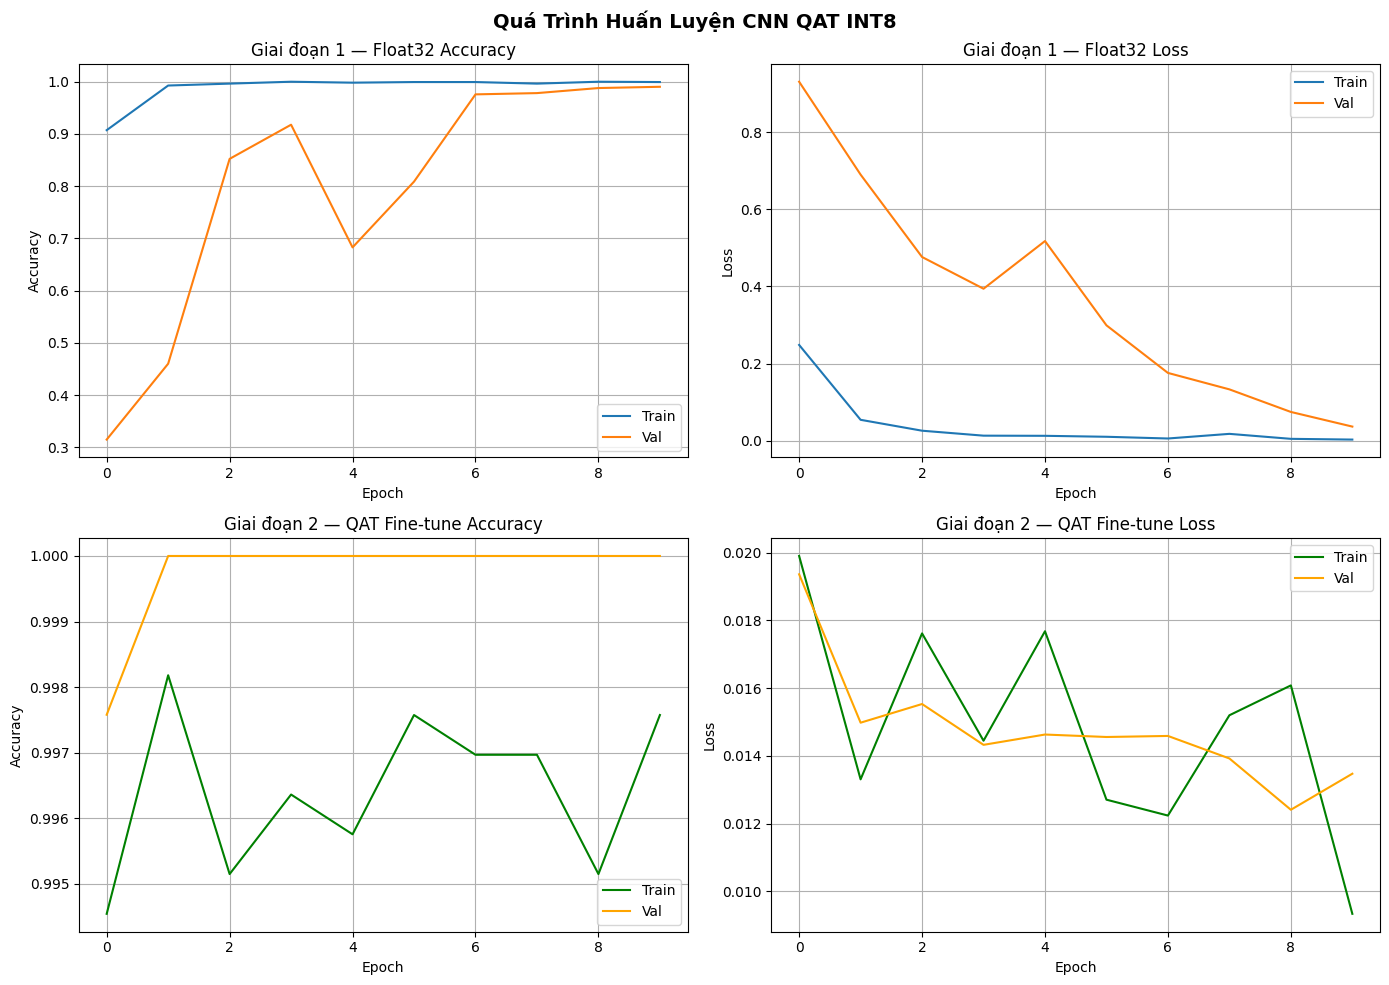

📊 Biểu đồ lưu tại: /content/drive/MyDrive/CNX/training_history.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Quá Trình Huấn Luyện CNN QAT INT8', fontsize=14, fontweight='bold')

# Float32 accuracy
axes[0,0].plot(history_f32.history['accuracy'],     label='Train')
axes[0,0].plot(history_f32.history['val_accuracy'], label='Val')
axes[0,0].set_title('Giai đoạn 1 — Float32 Accuracy')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(True)

# Float32 loss
axes[0,1].plot(history_f32.history['loss'],     label='Train')
axes[0,1].plot(history_f32.history['val_loss'], label='Val')
axes[0,1].set_title('Giai đoạn 1 — Float32 Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True)

# QAT accuracy
axes[1,0].plot(history_qat.history['accuracy'],     label='Train', color='green')
axes[1,0].plot(history_qat.history['val_accuracy'], label='Val',   color='orange')
axes[1,0].set_title('Giai đoạn 2 — QAT Fine-tune Accuracy')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend(); axes[1,0].grid(True)

# QAT loss
axes[1,1].plot(history_qat.history['loss'],     label='Train', color='green')
axes[1,1].plot(history_qat.history['val_loss'], label='Val',   color='orange')
axes[1,1].set_title('Giai đoạn 2 — QAT Fine-tune Loss')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')
axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_history.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'📊 Biểu đồ lưu tại: {plot_path}')

## 🔍 11. Đánh Giá Mô Hình

In [11]:
tic = time.time()
y_pred_raw = qat_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
toc = time.time()
print(f'⏱️  Thời gian inference: {toc - tic:.4f}s')

test_loss, test_acc = qat_model.evaluate(X_test, y_test, verbose=0)
print(f'\n📌 Test Accuracy : {test_acc:.4f}')
print(f'📌 Test Loss     : {test_loss:.4f}')

y_true = y_test.argmax(axis=1)
y_pred = y_pred_raw.argmax(axis=1)   # argmax thay softmax — đúng với hardware
target_names = ['Benign', 'Malware']

print('\n' + '='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_true, y_pred, target_names=target_names))

⏱️  Thời gian inference: 1.3213s

📌 Test Accuracy : 0.9966
📌 Test Loss     : 0.0198

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00       300
     Malware       1.00      0.99      1.00       584

    accuracy                           1.00       884
   macro avg       1.00      1.00      1.00       884
weighted avg       1.00      1.00      1.00       884



## 🔥 12. Confusion Matrix

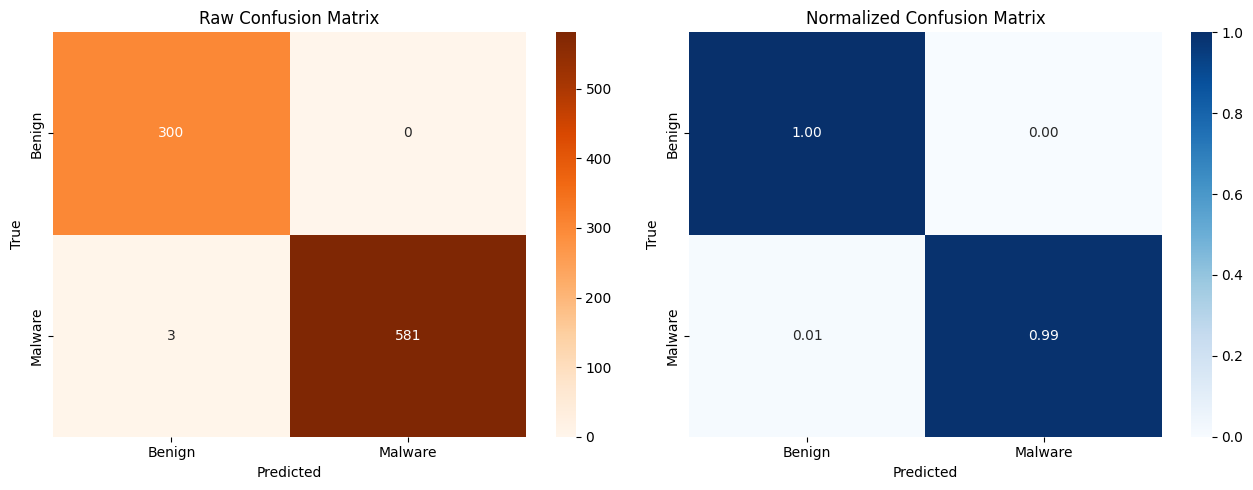

💾 .dat lưu tại: /content/drive/MyDrive/CNX/dat/conf_mat_qat_int8.dat


In [12]:
conf_mat      = confusion_matrix(y_true, y_pred)
conf_mat_norm = np.around(
    conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis], 2
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(conf_mat,      annot=True, fmt='d',    cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names, ax=ax1)
ax1.set_title('Raw Confusion Matrix'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

sns.heatmap(conf_mat_norm, annot=True, fmt='.2f',  cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax2)
ax2.set_title('Normalized Confusion Matrix'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Lưu .dat
dat_path = os.path.join(OUTPUT_DIR, 'dat', 'conf_mat_qat_int8.dat')
with open(dat_path, 'wb') as f:
    for line in np.matrix(conf_mat_norm):
        np.savetxt(f, line, fmt='%.2f')
print(f'💾 .dat lưu tại: {dat_path}')

## 💾 13. Export Weights INT8 cho Hardware

Sau khi QAT xong, extract weights thực sự về **numpy int8**  
— đây là giá trị sẽ được nạp thẳng vào ROM/BRAM trên phần cứng.

**Kèm theo `shift_params.json`** — chứa `SHIFT_BITS` cho từng layer  
để hardware biết dịch phải bao nhiêu bit sau khi tính MAC.

```
Hardware inference flow:
  acc_int32 = MAC(input_int8, weight_int8)
  acc_int8  = clip(acc_int32 >> SHIFT_BITS, -127, 127)
  activation= clip(acc_int8, 0, 127)   ← ReLU layers only
```

In [22]:
# ================================================================
# CELL 13 — FOLD BN + EXTRACT INT8 WEIGHTS + EXPORT JSON/EXCEL
# ================================================================
hw_dir = os.path.join(OUTPUT_DIR, 'hardware')
os.makedirs(hw_dir, exist_ok=True)

# ── Hàm fold BatchNorm vào Conv weight ───────────────────────────
def fold_bn_into_conv(conv_layer, bn_layer):
    """
    Fold BN vào Conv:
      w_fold[..., o] = w[..., o] * gamma[o] / sqrt(var[o] + eps)
      b_fold[o]      = (0 - mean[o]) * gamma[o] / sqrt(var[o] + eps) + beta[o]
    use_bias=False nên bias gốc = 0
    """
    w      = conv_layer.conv.kernel.numpy()   # (kH, kW, in_ch, out_ch)
    gamma  = bn_layer.gamma.numpy()
    beta   = bn_layer.beta.numpy()
    mean   = bn_layer.moving_mean.numpy()
    var    = bn_layer.moving_variance.numpy()
    eps    = 1e-3

    scale  = gamma / np.sqrt(var + eps)       # (out_ch,)
    w_fold = w * scale[np.newaxis, np.newaxis, np.newaxis, :]
    b_fold = (-mean) * scale + beta
    return w_fold, b_fold


def fold_bn_into_dense(dense_layer, bn_layer):
    """
    Fold BN vào Dense:
      w_fold[:, o] = w[:, o] * gamma[o] / sqrt(var[o] + eps)
      b_fold[o]    = (0 - mean[o]) * gamma[o] / sqrt(var[o] + eps) + beta[o]
    """
    w      = dense_layer.dense.kernel.numpy()  # (in_features, out_features)
    gamma  = bn_layer.gamma.numpy()
    beta   = bn_layer.beta.numpy()
    mean   = bn_layer.moving_mean.numpy()
    var    = bn_layer.moving_variance.numpy()
    eps    = 1e-3

    scale  = gamma / np.sqrt(var + eps)
    w_fold = w * scale[np.newaxis, :]
    b_fold = (-mean) * scale + beta
    return w_fold, b_fold


def quantize_folded_conv(w_fold, b_fold, q_max=127):
    """Quantize weight/bias đã fold BN (Conv) về INT8."""
    # Per-channel scale theo output channel (axis cuối)
    scale_w = np.max(np.abs(w_fold),
                     axis=tuple(range(len(w_fold.shape) - 1)),
                     keepdims=True)
    scale_w = np.maximum(scale_w, 1e-6)
    w_int8  = np.clip(np.round(w_fold / scale_w * q_max), -q_max, q_max).astype(np.int8)

    scale_b = np.maximum(np.abs(b_fold), 1e-6)
    b_int8  = np.clip(np.round(b_fold / scale_b * q_max), -q_max, q_max).astype(np.int8)
    return w_int8, b_int8


def quantize_folded_dense(w_fold, b_fold, q_max=127):
    """Quantize weight/bias đã fold BN (Dense) về INT8."""
    scale_w = np.maximum(np.max(np.abs(w_fold)), 1e-6)
    w_int8  = np.clip(np.round(w_fold / scale_w * q_max), -q_max, q_max).astype(np.int8)

    scale_b = np.maximum(np.max(np.abs(b_fold)), 1e-6)
    b_int8  = np.clip(np.round(b_fold / scale_b * q_max), -q_max, q_max).astype(np.int8)
    return w_int8, b_int8


# ── Fold BN + Quantize từng layer ────────────────────────────────
print('📤 Folding BN + Quantizing weights...')

# Conv1: fold BN → quantize → transpose sang hardware shape
conv1_layer           = qat_model.get_layer('Conv2D_1')
w_c1f, b_c1f         = fold_bn_into_conv(conv1_layer, conv1_layer.bn)
w_c1q, b_conv1_hw    = quantize_folded_conv(w_c1f, b_c1f)
w_conv1_hw            = w_c1q.transpose(3, 2, 0, 1)   # (16, 1, 3, 3)

# Conv2: fold BN → quantize → transpose
conv2_layer           = qat_model.get_layer('Conv2D_2')
w_c2f, b_c2f         = fold_bn_into_conv(conv2_layer, conv2_layer.bn)
w_c2q, b_conv2_hw    = quantize_folded_conv(w_c2f, b_c2f)
w_conv2_hw            = w_c2q.transpose(3, 2, 0, 1)   # (32, 16, 3, 3)

# Dense1: fold BN → quantize
dense1_layer          = qat_model.get_layer('Dense_1')
w_d1f, b_d1f         = fold_bn_into_dense(dense1_layer, dense1_layer.bn)
w_dense1_hw, b_dense1_hw = quantize_folded_dense(w_d1f, b_d1f)  # (416, 48)

# Dense2: không có BN, dùng get_int8_weights() trực tiếp
dense2_layer          = qat_model.get_layer('Dense_output')
w_dense2_hw, b_dense2_hw = dense2_layer.get_int8_weights()       # (48,2), (2,)

print('=== Weights sau fold BN + INT8 ===')
print(f'Conv1  W: {w_conv1_hw.shape}  B: {b_conv1_hw.shape}  '
      f'W=[{w_conv1_hw.min()},{w_conv1_hw.max()}]  B=[{b_conv1_hw.min()},{b_conv1_hw.max()}]')
print(f'Conv2  W: {w_conv2_hw.shape}  B: {b_conv2_hw.shape}  '
      f'W=[{w_conv2_hw.min()},{w_conv2_hw.max()}]  B=[{b_conv2_hw.min()},{b_conv2_hw.max()}]')
print(f'Dense1 W: {w_dense1_hw.shape} B: {b_dense1_hw.shape}  '
      f'W=[{w_dense1_hw.min()},{w_dense1_hw.max()}]  B=[{b_dense1_hw.min()},{b_dense1_hw.max()}]')
print(f'Dense2 W: {w_dense2_hw.shape} B: {b_dense2_hw.shape}  '
      f'W=[{w_dense2_hw.min()},{w_dense2_hw.max()}]  B=[{b_dense2_hw.min()},{b_dense2_hw.max()}]')

# ── Verify: so sánh forward pass fold vs Keras ───────────────────
print('\n=== Verify fold BN vs Keras float32 ===')
from tensorflow.keras import Model as KModel

sample     = X_test[:1]
QAT_ACTIVE = False

# Keras output từng layer
layer_names_check = ['Conv2D_1', 'MaxPooling_1', 'Conv2D_2', 'Flatten', 'Dense_1', 'Dense_output']
km = KModel(inputs=qat_model.input,
            outputs=[qat_model.get_layer(n).output for n in layer_names_check])
keras_outs = km(sample, training=False)

# Thủ công tính Conv1 với folded weights (float, chưa quantize) để verify
w_c1f_t = w_c1f.transpose(3, 2, 0, 1)   # (16,1,3,3) float
x_in    = sample.squeeze()               # (8,32)

def manual_conv_float(x_2d, w_folded, b_folded):
    """Conv float để verify fold BN đúng chưa."""
    H, W       = x_2d.shape
    oc, ic, kH, kW = w_folded.shape
    H_out, W_out   = H - kH + 1, W - kW + 1
    out = np.zeros((H_out, W_out, oc))
    x3d = x_2d[:, :, np.newaxis]
    for r in range(H_out):
        for c in range(W_out):
            patch = x3d[r:r+kH, c:c+kW, :]
            for o in range(oc):
                out[r, c, o] = np.sum(patch * w_folded[o].transpose(1,2,0)) + b_folded[o]
    return np.maximum(out, 0)   # ReLU

manual_c1  = manual_conv_float(x_in, w_c1f_t, b_c1f)
keras_c1   = keras_outs[0].numpy().squeeze()
max_diff_c1 = np.max(np.abs(manual_c1 - keras_c1))
print(f'Conv1 fold vs Keras max diff : {max_diff_c1:.6f}  '
      f'{"✅ OK" if max_diff_c1 < 0.01 else "❌ FAIL — kiểm tra lại fold"}')

# ── Lưu JSON ─────────────────────────────────────────────────────
def save_int8_weights_json(filepath):
    export = {
        'Conv1'  : {'weights': w_conv1_hw.tolist(), 'biases': b_conv1_hw.tolist(),
                    'w_shape': list(w_conv1_hw.shape), 'note': '[out_ch,in_ch,kH,kW] BN folded'},
        'Conv2'  : {'weights': w_conv2_hw.tolist(), 'biases': b_conv2_hw.tolist(),
                    'w_shape': list(w_conv2_hw.shape), 'note': '[out_ch,in_ch,kH,kW] BN folded'},
        'Dense1' : {'weights': w_dense1_hw.tolist(), 'biases': b_dense1_hw.tolist(),
                    'w_shape': list(w_dense1_hw.shape), 'note': '[in,out] BN folded'},
        'Dense2' : {'weights': w_dense2_hw.tolist(), 'biases': b_dense2_hw.tolist(),
                    'w_shape': list(w_dense2_hw.shape), 'note': '[in,out] no BN'},
        'dtype'  : 'int8',
        'bn_fold': 'BatchNorm folded into weights before quantization',
    }
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(export, f, indent=2)
    print(f'✅ weights_int8.json : {filepath}')

# ── Lưu Excel ────────────────────────────────────────────────────
def save_int8_weights_excel(filepath):
    with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
        for name, w, b in [
            ('Conv1',  w_conv1_hw,  b_conv1_hw),
            ('Conv2',  w_conv2_hw,  b_conv2_hw),
            ('Dense1', w_dense1_hw, b_dense1_hw),
            ('Dense2', w_dense2_hw, b_dense2_hw),
        ]:
            pd.DataFrame(w.reshape(-1, w.shape[-1]).astype(int)).to_excel(
                writer, sheet_name=f'{name}_W')
            pd.DataFrame(b.reshape(-1,1).astype(int), columns=['bias']).to_excel(
                writer, sheet_name=f'{name}_B')
    print(f'✅ weights_int8.xlsx : {filepath}')

json_path  = os.path.join(hw_dir, 'weights_int8.json')
excel_path = os.path.join(hw_dir, 'weights_int8.xlsx')
save_int8_weights_json(json_path)
save_int8_weights_excel(excel_path)

📤 Folding BN + Quantizing weights...
=== Weights sau fold BN + INT8 ===
Conv1  W: (16, 1, 3, 3)  B: (16,)  W=[-127,127]  B=[-127,127]
Conv2  W: (32, 16, 3, 3)  B: (32,)  W=[-127,127]  B=[-127,127]
Dense1 W: (416, 48) B: (48,)  W=[-127,106]  B=[-127,88]
Dense2 W: (48, 2) B: (2,)  W=[-127,120]  B=[0,0]

=== Verify fold BN vs Keras float32 ===
Conv1 fold vs Keras max diff : 0.000001  ✅ OK
✅ weights_int8.json : /content/drive/MyDrive/CNX/hardware/weights_int8.json
✅ weights_int8.xlsx : /content/drive/MyDrive/CNX/hardware/weights_int8.xlsx


In [23]:
# ================================================================
# CELL 13.1 — TEST 5 ẢNH + XUẤT in_32.hex CHO TỪNG CASE
# ================================================================
# Lấy 5 ảnh test (2 benign + 3 malware) để kiểm tra model
# Xuất file in_32.hex theo đặc tả: 64 words, 4 pixels/word, row-major
# ================================================================

import random

# ── Hàm xuất in_32.hex ───────────────────────────────────────────
def export_input_hex(image_float32: np.ndarray, filepath: str):
    """
    Chuyển ảnh float32 [0,1] shape (8,32,1) → uint8 [0,255]
    → pack 4 pixels/word big-endian → lưu .hex (64 dòng)
    """
    # Chuyển float [0,1] → uint8 [0,255]
    img_uint8 = np.clip(np.round(image_float32.squeeze() * 255), 0, 255).astype(np.uint8)
    assert img_uint8.shape == (8, 32), f'Expect (8,32), got {img_uint8.shape}'

    flat      = img_uint8.flatten()           # row-major: (row0,col0)..(row7,col31)
    words     = flat.reshape(-1, 4)           # 64 words × 4 bytes
    hex_lines = [
        f"{(int(r[0])<<24)|(int(r[1])<<16)|(int(r[2])<<8)|int(r[3]):08x}"
        for r in words
    ]
    assert len(hex_lines) == 64, f'Expect 64 words, got {len(hex_lines)}'
    with open(filepath, 'w') as f:
        f.write('\n'.join(hex_lines) + '\n')
    return img_uint8, hex_lines


# ── Hàm inference trên 1 ảnh ─────────────────────────────────────
def predict_one(image_float32: np.ndarray, model, true_label: int):
    """
    image_float32: shape (8, 32, 1)
    true_label   : 0 = Benign, 1 = Malware
    Trả về dict kết quả
    """
    QAT_ACTIVE = False
    inp        = image_float32[np.newaxis, ...]          # (1, 8, 32, 1)
    raw_out    = model(inp, training=False).numpy()[0]   # shape (2,) — raw INT32
    pred_class = int(np.argmax(raw_out))
    pred_name  = 'Benign'  if pred_class == 0 else 'Malware'
    true_name  = 'Benign'  if true_label  == 0 else 'Malware'
    correct    = (pred_class == true_label)
    return {
        'true_label'  : true_name,
        'pred_label'  : pred_name,
        'raw_out_0'   : float(raw_out[0]),   # score Benign
        'raw_out_1'   : float(raw_out[1]),   # score Malware
        'correct'     : correct,
    }


# ── Chọn 5 test case ─────────────────────────────────────────────
# Lấy index từ X_test/y_test: 2 Benign + 3 Malware
random.seed(RANDOM_SEED)

benign_idx  = [i for i in range(len(y_test)) if y_test[i][0] == 1]
malware_idx = [i for i in range(len(y_test)) if y_test[i][1] == 1]

chosen_benign  = random.sample(benign_idx,  2)
chosen_malware = random.sample(malware_idx, 3)
test_cases     = [(i, 0) for i in chosen_benign] + [(i, 1) for i in chosen_malware]

print('=' * 65)
print('TEST 5 ẢNH MẪU')
print('=' * 65)

test_dir = os.path.join(hw_dir, 'test_cases')
os.makedirs(test_dir, exist_ok=True)

results     = []
hex_summary = []

for case_no, (idx, true_label) in enumerate(test_cases):
    image   = X_test[idx]                          # (8, 32, 1) float32
    result  = predict_one(image, qat_model, true_label)

    # Xuất in_32.hex
    hex_path              = os.path.join(test_dir, f'test{case_no+1}_in32.hex')
    img_uint8, hex_lines  = export_input_hex(image, hex_path)

    status = '✅ CORRECT' if result['correct'] else '❌ WRONG'
    print(f'\n[Case {case_no+1}] index={idx} | True={result["true_label"]:7s} | '
          f'Pred={result["pred_label"]:7s} | '
          f'Score=[{result["raw_out_0"]:7.2f}, {result["raw_out_1"]:7.2f}] | {status}')
    print(f'  → {os.path.basename(hex_path)} ({len(hex_lines)} words)')

    # Hiển thị pixel map nhỏ
    print(f'  Pixel map (uint8, 8×32):')
    for row in range(8):
        row_vals = ' '.join(f'{img_uint8[row, col]:3d}' for col in range(32))
        print(f'    row{row}: {row_vals}')

    results.append({
        'Case'        : case_no + 1,
        'Test index'  : idx,
        'True label'  : result['true_label'],
        'Pred label'  : result['pred_label'],
        'Score Benign': round(result['raw_out_0'], 4),
        'Score Malware': round(result['raw_out_1'], 4),
        'Correct'     : '✓' if result['correct'] else '✗',
        'hex file'    : f'test{case_no+1}_in32.hex',
    })
    hex_summary.append({
        'case'       : case_no + 1,
        'true_label' : result['true_label'],
        'pred_label' : result['pred_label'],
        'correct'    : result['correct'],
        'hex_lines'  : hex_lines,          # 64 dòng hex
        'img_uint8'  : img_uint8.tolist(), # 8×32 pixel values
    })

# ── Tổng kết 5 test case ─────────────────────────────────────────
df_results = pd.DataFrame(results)
print('\n' + '=' * 65)
print('TỔNG KẾT 5 TEST CASE')
print('=' * 65)
print(df_results.to_string(index=False))
n_correct = sum(1 for r in results if r['Correct'] == '✓')
print(f'\n✅ Kết quả: {n_correct}/5 đúng')

# ── Lưu kết quả test vào Excel (sheet mới) ───────────────────────
with pd.ExcelWriter(excel_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_results.to_excel(writer, sheet_name='Test_Cases', index=False)
print(f'✅ Sheet Test_Cases → {excel_path}')

# ── Lưu kết quả test vào JSON ─────────────────────────────────────
test_json_path = os.path.join(test_dir, 'test_results.json')
with open(test_json_path, 'w', encoding='utf-8') as f:
    json.dump([{
        'case'        : r['case'],
        'true_label'  : r['true_label'],
        'pred_label'  : r['pred_label'],
        'correct'     : r['correct'],
        'hex_file'    : f'test{r["case"]}_in32.hex',
        'img_uint8'   : r['img_uint8'],
        'hex_preview' : r['hex_lines'][:4],   # 4 dòng đầu để verify
    } for r in hex_summary], f, indent=2)
print(f'✅ test_results.json → {test_json_path}')

print(f'\n📁 Toàn bộ file test lưu tại: {test_dir}')
print('   Gồm: test1_in32.hex .. test5_in32.hex + test_results.json')

TEST 5 ẢNH MẪU

[Case 1] index=200 | True=Benign  | Pred=Benign  | Score=[   3.81,   -2.43] | ✅ CORRECT
  → test1_in32.hex (64 words)
  Pixel map (uint8, 8×32):
    row0: 117 111 117 118 119 124 124 112 121 130 123 125 125 120 121 119 114 125 122 121 119 122 117 116 113 117 114 113 121 122 111 126
    row1: 116 122 124 122 108 121 124 124 115 114 125 120 120 126 127 111 129 124 126 125 125 128 126 107 130 131 123 143 131 121 124 128
    row2: 124 119 124 121 126 125 135 133 114 119 123 121 115 122 118 126 129 128 127 143 131 131 125 129 137 130 132 146 142 132 138 141
    row3: 136 126 138 139 135 145 133 133 136 139 143 136 138 147 137 128 123 125 120 109 107 111 111 123 117 110 128 124 126 123 121 125
    row4: 126 132 135 127 128 135 132 133 129 127 119 133 124 127 135 124 124 132 122 126 120 121 138 125 116 124 116 108 105 114 115 111
    row5: 132 123 120 120 123 123 126 116 125 115 118 136 120 121 111 106 125 130 129 132 117 124 138 124 123 125 129 127 125 120 123 132
    row6: 1

In [27]:
# ================================================================
# CELL 13.2 — HARDWARE INT8 FORWARD PASS (PURE INTEGER SIMULATION)
# Dùng weights đã fold BN + quantize INT8
# Input: uint8 → shift về signed int8 [-128, 127]
# Mỗi layer: MAC integer → shift → clip → INT8
# ================================================================

# ── Kiểm tra shift_params đã có chưa ─────────────────────────────
sb_conv1  = shift_params['Conv1' ]['shift_bits']   # = 10
sb_conv2  = shift_params['Conv2' ]['shift_bits']   # = 12
sb_dense1 = shift_params['Dense1']['shift_bits']   # = 11
print(f'Shift bits — Conv1:{sb_conv1}  Conv2:{sb_conv2}  Dense1:{sb_dense1}')


# ── Các hàm hardware simulation ──────────────────────────────────
def hw_conv2d_int8(x_int8, w_int8, b_int8, shift_bits):
    """
    Conv2D thuần INT8.
    x_int8 : (H, W, in_ch)            int8/int16
    w_int8 : (out_ch, in_ch, kH, kW)  int8
    b_int8 : (out_ch,)                 int8
    return : acc_raw(INT32), acc_shifted(INT32), out(INT8 sau ReLU)
    """
    H, W, in_ch       = x_int8.shape
    out_ch, _, kH, kW = w_int8.shape
    H_out = H - kH + 1
    W_out = W - kW + 1
    acc   = np.zeros((H_out, W_out, out_ch), dtype=np.int32)

    for r in range(H_out):
        for c in range(W_out):
            patch = x_int8[r:r+kH, c:c+kW, :].astype(np.int32)   # (kH,kW,in_ch)
            for o in range(out_ch):
                # w_int8[o]: (in_ch, kH, kW) → transpose → (kH, kW, in_ch)
                acc[r, c, o] = np.sum(patch * w_int8[o].transpose(1,2,0).astype(np.int32))

    acc        += b_int8.astype(np.int32)[np.newaxis, np.newaxis, :]
    acc_shifted = acc >> shift_bits
    out_int8    = np.clip(acc_shifted, 0, 127).astype(np.int8)   # ReLU + clip
    return acc, acc_shifted, out_int8


def hw_maxpool2d_int8(x_int8, pool=2):
    """MaxPool2D (2×2, stride=2) thuần INT8."""
    H, W, C = x_int8.shape
    out     = np.zeros((H//pool, W//pool, C), dtype=np.int8)
    for r in range(H//pool):
        for c in range(W//pool):
            out[r, c] = np.max(
                x_int8[r*pool:(r+1)*pool, c*pool:(c+1)*pool, :], axis=(0,1)
            )
    return out


def hw_dense_int8(x_int8, w_int8, b_int8, shift_bits, relu=True):
    """
    Dense thuần INT8.
    x_int8 : (in_features,)              int8
    w_int8 : (in_features, out_features) int8
    return : acc_raw(INT32), acc_shifted(INT32), out(INT8 or INT32)
    """
    acc         = np.dot(x_int8.astype(np.int32), w_int8.astype(np.int32))
    acc        += b_int8.astype(np.int32)
    acc_shifted = acc >> shift_bits
    if relu:
        out = np.clip(acc_shifted, 0, 127).astype(np.int8)
    else:
        out = acc   # giữ INT32 thô cho output layer
    return acc, acc_shifted, out


# ── Verify flatten order: numpy vs Keras ─────────────────────────
print('\n=== Verify flatten order ===')
sample      = X_test[:1]
QAT_ACTIVE  = False
km_flat     = KModel(inputs=qat_model.input,
                     outputs=qat_model.get_layer('Flatten').output)
keras_flat  = km_flat(sample, training=False).numpy().squeeze()  # float32

# Tính thủ công Conv1→MaxPool→Conv2→Flatten với folded float weights
def manual_conv_float(x_3d, w_f, b_f):
    oc, ic, kH, kW     = w_f.shape
    H, W, _            = x_3d.shape
    H_out, W_out       = H-kH+1, W-kW+1
    out                = np.zeros((H_out, W_out, oc))
    for r in range(H_out):
        for c in range(W_out):
            patch = x_3d[r:r+kH, c:c+kW, :]
            for o in range(oc):
                out[r,c,o] = np.sum(patch * w_f[o].transpose(1,2,0)) + b_f[o]
    return np.maximum(out, 0)

def manual_maxpool(x, p=2):
    H, W, C = x.shape
    out     = np.zeros((H//p, W//p, C))
    for r in range(H//p):
        for c in range(W//p):
            out[r,c] = np.max(x[r*p:(r+1)*p, c*p:(c+1)*p, :], axis=(0,1))
    return out

x_in   = sample.squeeze()[:, :, np.newaxis]        # (8,32,1) float
c1f    = manual_conv_float(x_in, w_c1f.transpose(3,2,0,1), b_c1f)
mp1f   = manual_maxpool(c1f)
c2f    = manual_conv_float(mp1f, w_c2f.transpose(3,2,0,1), b_c2f)
flat_f = c2f.flatten()   # numpy C-order flatten

max_diff_flat = np.max(np.abs(flat_f - keras_flat))
print(f'Flatten max diff (folded float vs Keras): {max_diff_flat:.6f}  '
      f'{"✅ OK — flatten order đúng" if max_diff_flat < 0.01 else "❌ FAIL — flatten order sai"}')

# ── Chạy hardware simulation ──────────────────────────────────────
debug_dir = os.path.join(hw_dir, 'debug_layers')
os.makedirs(debug_dir, exist_ok=True)

print('\n' + '='*65)
print('HARDWARE INT8 FORWARD PASS SIMULATION')
print('='*65)

for case_no, (idx, true_label) in enumerate(test_cases):
    image     = X_test[idx]
    true_name = 'Benign' if true_label == 0 else 'Malware'
    print(f'\n[Case {case_no+1}] True={true_name}')

    excel_debug = os.path.join(debug_dir, f'test{case_no+1}_layer_debug.xlsx')

    with pd.ExcelWriter(excel_debug, engine='openpyxl') as writer:

        # ── 00 Input ─────────────────────────────────────────────
        x0_uint8 = np.clip(np.round(image.squeeze() * 255), 0, 255).astype(np.uint8)
        # Shift về signed: pixel 0→-128, pixel 128→0, pixel 255→127
        x0_int8  = (x0_uint8.astype(np.int16) - 128).astype(np.int8)

        pd.DataFrame(
            x0_uint8,
            index  =[f'row{r}' for r in range(8)],
            columns=[f'col{c}' for c in range(32)]
        ).to_excel(writer, sheet_name='00_Input')
        pd.DataFrame(
            x0_int8.astype(int),
            index  =[f'row{r}' for r in range(8)],
            columns=[f'col{c}' for c in range(32)]
        ).to_excel(writer, sheet_name='00_Input', startrow=0, startcol=35)
        ws = writer.sheets['00_Input']
        ws.cell(row=1, column=1,  value='[uint8 — nạp vào BRAM_IF1]')
        ws.cell(row=1, column=36, value='[int8 signed — input vào Conv1 MAC]')
        print(f'  Input  uint8=[{x0_uint8.min()},{x0_uint8.max()}]  '
              f'int8=[{x0_int8.min()},{x0_int8.max()}]')

        # ── 01 Conv1 ─────────────────────────────────────────────
        x0_3d            = x0_int8[:, :, np.newaxis]           # (8,32,1)
        acc1, sh1, x1    = hw_conv2d_int8(x0_3d, w_conv1_hw, b_conv1_hw, sb_conv1)
        h, w, c          = x1.shape
        rn = [f'r{r}c{cc}' for r in range(h) for cc in range(w)]
        cn = [f'ch{i}' for i in range(c)]
        gap = c + 3
        pd.DataFrame(acc1.reshape(h*w,c), index=rn, columns=cn).to_excel(
            writer, sheet_name='01_Conv1', startrow=1, startcol=0)
        pd.DataFrame(sh1.reshape(h*w,c),  index=rn, columns=cn).to_excel(
            writer, sheet_name='01_Conv1', startrow=1, startcol=gap)
        pd.DataFrame(x1.reshape(h*w,c).astype(int), index=rn, columns=cn).to_excel(
            writer, sheet_name='01_Conv1', startrow=1, startcol=gap*2)
        ws = writer.sheets['01_Conv1']
        ws.cell(row=1, column=1,       value='[INT32 acc raw]')
        ws.cell(row=1, column=gap+1,   value=f'[INT32 acc>>{sb_conv1}]')
        ws.cell(row=1, column=gap*2+1, value='[INT8 out+ReLU ← so sánh TB]')
        print(f'  Conv1  acc=[{acc1.min()},{acc1.max()}]  '
              f'out=[{x1.min()},{x1.max()}]  shape={x1.shape}')

        # ── 02 MaxPool ───────────────────────────────────────────
        x2      = hw_maxpool2d_int8(x1)                        # (3,15,16)
        h, w, c = x2.shape
        rn      = [f'r{r}c{cc}' for r in range(h) for cc in range(w)]
        pd.DataFrame(x2.reshape(h*w,c).astype(int), index=rn,
                     columns=[f'ch{i}' for i in range(c)]).to_excel(
            writer, sheet_name='02_MaxPool')
        writer.sheets['02_MaxPool'].cell(
            row=1, column=1, value='[INT8 output MaxPool2D(2×2) ← so sánh TB]')
        print(f'  MaxPool out=[{x2.min()},{x2.max()}]  shape={x2.shape}')

        # ── 03 Conv2 ─────────────────────────────────────────────
        acc2, sh2, x3    = hw_conv2d_int8(x2, w_conv2_hw, b_conv2_hw, sb_conv2)
        h, w, c          = x3.shape
        rn  = [f'r{r}c{cc}' for r in range(h) for cc in range(w)]
        cn2 = [f'ch{i}' for i in range(c)]
        gap = c + 3
        pd.DataFrame(acc2.reshape(h*w,c), index=rn, columns=cn2).to_excel(
            writer, sheet_name='03_Conv2', startrow=1, startcol=0)
        pd.DataFrame(sh2.reshape(h*w,c),  index=rn, columns=cn2).to_excel(
            writer, sheet_name='03_Conv2', startrow=1, startcol=gap)
        pd.DataFrame(x3.reshape(h*w,c).astype(int), index=rn, columns=cn2).to_excel(
            writer, sheet_name='03_Conv2', startrow=1, startcol=gap*2)
        ws = writer.sheets['03_Conv2']
        ws.cell(row=1, column=1,       value='[INT32 acc raw]')
        ws.cell(row=1, column=gap+1,   value=f'[INT32 acc>>{sb_conv2}]')
        ws.cell(row=1, column=gap*2+1, value='[INT8 out+ReLU ← so sánh TB]')
        print(f'  Conv2  acc=[{acc2.min()},{acc2.max()}]  '
              f'out=[{x3.min()},{x3.max()}]  shape={x3.shape}')

        # ── 04 Flatten ───────────────────────────────────────────
        x4 = x3.flatten()                                      # (416,) int8
        pd.DataFrame(
            {'value': x4.astype(int)},
            index=[f'f{i}' for i in range(len(x4))]
        ).to_excel(writer, sheet_name='04_Flatten')
        writer.sheets['04_Flatten'].cell(
            row=1, column=1, value='[INT8 416 features ← input Dense1]')
        print(f'  Flatten out=[{x4.min()},{x4.max()}]  shape={x4.shape}')

        # ── 05 Dense1 ────────────────────────────────────────────
        acc5, sh5, x5 = hw_dense_int8(x4, w_dense1_hw, b_dense1_hw, sb_dense1, relu=True)
        pd.DataFrame({
            'acc_int32'  : acc5.astype(int),
            f'acc>>{sb_dense1}': sh5.astype(int),
            'out_int8'   : x5.astype(int),
        }, index=[f'n{i}' for i in range(48)]).to_excel(writer, sheet_name='05_Dense1')
        writer.sheets['05_Dense1'].cell(
            row=1, column=1,
            value=f'[acc_int32 | acc>>{sb_dense1} | INT8+ReLU ← so sánh TB]')
        print(f'  Dense1 acc=[{acc5.min()},{acc5.max()}]  '
              f'out=[{x5.min()},{x5.max()}]  shape={x5.shape}')

        # ── 06 Dense2 output ─────────────────────────────────────
        acc6, _, _ = hw_dense_int8(x5, w_dense2_hw, b_dense2_hw, shift_bits=0, relu=False)
        pred_class = int(np.argmax(acc6))
        pred_name  = 'Benign' if pred_class == 0 else 'Malware'
        correct    = '✓ CORRECT' if pred_name == true_name else '✗ WRONG'

        pd.DataFrame({
            'neuron'  : ['n0 (Benign)', 'n1 (Malware)'],
            'INT32 raw': acc6.tolist(),
            'decision': ['← WIN' if pred_class==0 else '',
                         '← WIN' if pred_class==1 else ''],
        }).to_excel(writer, sheet_name='06_Dense2', index=False)
        ws = writer.sheets['06_Dense2']
        ws.cell(row=5, column=1, value=f'Pred  : {pred_name}')
        ws.cell(row=6, column=1, value=f'True  : {true_name}')
        ws.cell(row=7, column=1, value=f'Result: {correct}')
        print(f'  Dense2 acc={acc6.tolist()}  pred={pred_name}  {correct}')

        # ── ZZ_Decision ──────────────────────────────────────────
        pd.DataFrame([
            {'Field': 'True label',              'Value': true_name},
            {'Field': 'Pred label',              'Value': pred_name},
            {'Field': 'Result',                  'Value': correct},
            {'Field': 'Dense2 acc[0] Benign',    'Value': int(acc6[0])},
            {'Field': 'Dense2 acc[1] Malware',   'Value': int(acc6[1])},
            {'Field': 'Input quantize',          'Value': 'uint8 - 128 → int8 signed'},
            {'Field': 'BN treatment',            'Value': 'Folded into weights'},
            {'Field': 'Shift Conv1',             'Value': sb_conv1},
            {'Field': 'Shift Conv2',             'Value': sb_conv2},
            {'Field': 'Shift Dense1',            'Value': sb_dense1},
            {'Field': 'Shift Dense2',            'Value': 'none — raw INT32'},
            {'Field': 'Decision',                'Value': 'argmax(acc) — no softmax'},
        ]).to_excel(writer, sheet_name='ZZ_Decision', index=False)

    print(f'  💾 {os.path.basename(excel_debug)}')

print(f'\n✅ Pure INT8 simulation lưu tại: {debug_dir}')
print('\nCấu trúc mỗi Excel:')
print('  00_Input    : uint8 [0,255] | int8 signed [-128,127]')
print('  01_Conv1    : INT32 acc raw | INT32>>shift | INT8+ReLU')
print('  02_MaxPool  : INT8 output')
print('  03_Conv2    : INT32 acc raw | INT32>>shift | INT8+ReLU')
print('  04_Flatten  : INT8 416 features')
print('  05_Dense1   : INT32 acc | INT32>>shift | INT8+ReLU')
print('  06_Dense2   : INT32 raw accumulator — quyết định cuối')
print('  ZZ_Decision : Summary')

Shift bits — Conv1:10  Conv2:12  Dense1:11

=== Verify flatten order ===
Flatten max diff (folded float vs Keras): 0.000002  ✅ OK — flatten order đúng

HARDWARE INT8 FORWARD PASS SIMULATION

[Case 1] True=Benign
  Input  uint8=[105,155]  int8=[-23,27]
  Conv1  acc=[-7652,7337]  out=[0,7]  shape=(6, 30, 16)
  MaxPool out=[0,7]  shape=(3, 15, 16)
  Conv2  acc=[-5369,8150]  out=[0,1]  shape=(1, 13, 32)
  Flatten out=[0,1]  shape=(416,)
  Dense1 acc=[-337,273]  out=[0,0]  shape=(48,)
  Dense2 acc=[0, 0]  pred=Benign  ✓ CORRECT
  💾 test1_layer_debug.xlsx

[Case 2] True=Benign
  Input  uint8=[96,150]  int8=[-32,22]
  Conv1  acc=[-8218,7802]  out=[0,7]  shape=(6, 30, 16)
  MaxPool out=[0,7]  shape=(3, 15, 16)
  Conv2  acc=[-7020,6074]  out=[0,1]  shape=(1, 13, 32)
  Flatten out=[0,1]  shape=(416,)
  Dense1 acc=[-418,242]  out=[0,0]  shape=(48,)
  Dense2 acc=[0, 0]  pred=Benign  ✓ CORRECT
  💾 test2_layer_debug.xlsx

[Case 3] True=Malware
  Input  uint8=[70,141]  int8=[-58,13]
  Conv1  acc=[-14

In [29]:
# ── Tìm shift tối ưu theo pipeline thực tế ───────────────────────
# Thay vì tính độc lập từng layer với input lý thuyết,
# tính shift theo output thực tế của layer trước

print('Tìm shift tối ưu theo pipeline thực tế...\n')

# Thử các tổ hợp shift để tối đa hóa range output Dense1
best_acc   = 0
best_combo = None
results    = []

# Grid search shift trong range hợp lý
for sh1 in range(3, 8):       # Conv1
    for sh2 in range(5, 10):  # Conv2
        for sh3 in range(5, 10):  # Dense1

            correct = 0
            dense1_ranges = []

            for idx in range(len(X_test)):
                image    = X_test[idx]
                x0_uint8 = np.clip(np.round(image.squeeze()*255),0,255).astype(np.uint8)
                x0_int8  = (x0_uint8.astype(np.int16)-128).astype(np.int8)

                acc1,_,x1 = hw_conv2d_int8(x0_int8[:,:,np.newaxis],
                                            w_conv1_hw, b_conv1_hw, sh1)
                x2        = hw_maxpool2d_int8(x1)
                acc2,_,x3 = hw_conv2d_int8(x2, w_conv2_hw, b_conv2_hw, sh2)
                x4        = x3.flatten()
                acc5,_,x5 = hw_dense_int8(x4, w_dense1_hw, b_dense1_hw, sh3, relu=True)
                acc6,_,_  = hw_dense_int8(x5, w_dense2_hw, b_dense2_hw, 0,   relu=False)

                pred  = int(np.argmax(acc6))
                true  = int(y_test[idx].argmax())
                correct += (pred == true)
                dense1_ranges.append(int(x5.max()))

            acc_pct  = correct / len(X_test) * 100
            d1_range = np.mean(dense1_ranges)
            results.append((sh1, sh2, sh3, acc_pct, d1_range))

            if acc_pct > best_acc:
                best_acc   = acc_pct
                best_combo = (sh1, sh2, sh3)
                print(f'  ✅ New best: sh1={sh1} sh2={sh2} sh3={sh3} '
                      f'acc={acc_pct:.1f}% dense1_max_avg={d1_range:.1f}')

print(f'\n{"="*55}')
print(f'BEST: Conv1_shift={best_combo[0]}  Conv2_shift={best_combo[1]}  '
      f'Dense1_shift={best_combo[2]}')
print(f'ACC : {best_acc:.2f}%')

# Cập nhật shift_params
shift_params['Conv1' ]['shift_bits'] = best_combo[0]
shift_params['Conv2' ]['shift_bits'] = best_combo[1]
shift_params['Dense1']['shift_bits'] = best_combo[2]

sp_path = os.path.join(hw_dir, 'shift_params.json')
with open(sp_path, 'w', encoding='utf-8') as f:
    json.dump(shift_params, f, indent=2)
print(f'✅ shift_params.json đã cập nhật')
print('→ Chạy lại cell 13.2 với shift bits tối ưu')

Tìm shift tối ưu theo pipeline thực tế...

  ✅ New best: sh1=3 sh2=5 sh3=5 acc=66.3% dense1_max_avg=127.0
  ✅ New best: sh1=3 sh2=5 sh3=8 acc=66.4% dense1_max_avg=127.0


KeyboardInterrupt: 

In [20]:
# So sánh flatten numpy vs Keras
from tensorflow.keras import Model as KModel
flat_layer = KModel(inputs=qat_model.input,
                    outputs=qat_model.get_layer('Flatten').output)
keras_flat = flat_layer(image[np.newaxis,...], training=False).numpy().squeeze()
print("Keras flatten range:", keras_flat.min(), keras_flat.max())
print("Numpy flatten range:", x4.min(), x4.max())
print("Thứ tự khớp:", np.allclose(keras_flat, x4.astype(float), atol=1.0))

Keras flatten range: 0.0 2.189425
Numpy flatten range: 0 127
Thứ tự khớp: False


## 🏗️ 14. Export BRAM .hex theo đặc tả;

In [18]:
# ================================================================
# CELL 14 — EXPORT BRAM .HEX FILES (theo đặc tả CNN Accelerator)
# ================================================================
#
# Quy tắc packing (từ đặc tả):
#   Big-endian: weight đầu tiên trong chuỗi ở MSB (byte 3)
#   BRAM word 32-bit: [byte3 byte2 byte1 byte0]
#   → byte3 = weight[i+0], byte2 = weight[i+1],
#     byte1 = weight[i+2], byte0 = weight[i+3]
#
# Layout từng BRAM:
#   BRAM_W1 : Conv1  — 40   words  (36 weight + 4 bias)
#   BRAM_W2 : Conv2  — 1160 words  (1152 weight + 8 bias)
#   BRAM_W3 : Dense1 — 5004 words  (4992 weight + 12 bias)
#   BRAM_W4 : Dense2 — 50   words  (48 weight + 1 bias word + pad)
#   BRAM_IF1: Input  — 64   words  (256 pixels / 4)
# ================================================================

def pack_to_hex(weights_8bit: np.ndarray) -> list:
    """
    Pack array int8/uint8 → list hex string 32-bit (big-endian).
    Pad zeros nếu length không chia hết cho 4.
    """
    flat = weights_8bit.flatten().astype(np.uint8)
    pad  = (4 - len(flat) % 4) % 4
    flat = np.append(flat, np.zeros(pad, dtype=np.uint8))
    words = flat.reshape(-1, 4)
    return [
        f"{(int(r[0])<<24)|(int(r[1])<<16)|(int(r[2])<<8)|int(r[3]):08x}"
        for r in words
    ]

def save_hex(filepath: str, hex_lines: list):
    with open(filepath, 'w') as f:
        f.write('\n'.join(hex_lines) + '\n')
    print(f'  → {os.path.basename(filepath):15s} : {len(hex_lines):5d} words '
          f'({len(hex_lines)*4} bytes)')


# ── BRAM_W1: Conv1 ───────────────────────────────────────────────
# Layout: 2 batches × 9 kpos × 2 words/pos = 36 words + 4 bias words = 40
def export_w1(w, b, filepath):
    """
    w shape: (16, 1, 3, 3) → [out_ch, in_ch, row, col]
    b shape: (16,)
    """
    data = []
    for batch in range(2):           # batch 0: ch0-7, batch 1: ch8-15
        for k in range(9):           # 9 kernel positions, row-major
            row_k, col_k = k // 3, k % 3
            for half in range(2):    # word 0: PE0-3, word 1: PE4-7
                for pe in range(4):
                    ch = batch * 8 + half * 4 + pe
                    data.append(w[ch, 0, row_k, col_k])
    data.extend(b.tolist())          # 16 biases cuối (4 words)
    hex_lines = pack_to_hex(np.array(data, dtype=np.int8))
    assert len(hex_lines) == 40, f'W1 expect 40 words, got {len(hex_lines)}'
    save_hex(filepath, hex_lines)


# ── BRAM_W2: Conv2 ───────────────────────────────────────────────
# Layout: 4 batches × 16 in_ch × 9 kpos × 2 words = 1152 + 8 bias = 1160
def export_w2(w, b, filepath):
    """
    w shape: (32, 16, 3, 3) → [out_ch, in_ch, row, col]
    b shape: (32,)
    """
    data = []
    for batch in range(4):           # batch 0: out_ch 0-7, ..., batch 3: 24-31
        for in_ch in range(16):
            for k in range(9):
                row_k, col_k = k // 3, k % 3
                for half in range(2):
                    for pe in range(4):
                        out_ch = batch * 8 + half * 4 + pe
                        data.append(w[out_ch, in_ch, row_k, col_k])
    data.extend(b.tolist())          # 32 biases (8 words)
    hex_lines = pack_to_hex(np.array(data, dtype=np.int8))
    assert len(hex_lines) == 1160, f'W2 expect 1160 words, got {len(hex_lines)}'
    save_hex(filepath, hex_lines)


# ── BRAM_W3: Dense1 ──────────────────────────────────────────────
# Layout: 6 batches × 416 inputs × 2 words = 4992 + 12 bias = 5004
def export_w3(w, b, filepath):
    """
    w shape: (416, 48) → [in_features, out_features]
    b shape: (48,)
    """
    data = []
    for batch in range(6):           # batch 0: neuron 0-7, ..., batch 5: 40-47
        for i in range(416):
            for half in range(2):    # PE0-3, PE4-7
                for pe in range(4):
                    neuron = batch * 8 + half * 4 + pe
                    data.append(w[i, neuron])
    data.extend(b.tolist())          # 48 biases (12 words)
    hex_lines = pack_to_hex(np.array(data, dtype=np.int8))
    assert len(hex_lines) == 5004, f'W3 expect 5004 words, got {len(hex_lines)}'
    save_hex(filepath, hex_lines)


# ── BRAM_W4: Dense2 ──────────────────────────────────────────────
# Layout: 48 input words (4 bytes/word: w_n0, w_n1, 0x00, 0x00)
#         + 1 bias word  (bias_n0, bias_n1, 0x00, 0x00) = 49 words → pad 50
def export_w4(w, b, filepath):
    """
    w shape: (48, 2)
    b shape: (2,)
    Layout: 48 input words + 1 bias word + 1 padding word = 50 words
    Mỗi word: [w_n0, w_n1, 0x00, 0x00]
    """
    data = []
    for i in range(48):
        data.append(w[i, 0])   # neuron 0
        data.append(w[i, 1])   # neuron 1
        data.append(0)          # padding
        data.append(0)          # padding
    # bias word
    data.append(b[0])
    data.append(b[1])
    data.append(0)
    data.append(0)
    # padding word để đủ 50 words
    data.append(0)
    data.append(0)
    data.append(0)
    data.append(0)
    hex_lines = pack_to_hex(np.array(data, dtype=np.int8))
    assert len(hex_lines) == 50, f'W4 expect 50 words, got {len(hex_lines)}'
    save_hex(filepath, hex_lines)


# ── BRAM_IF1: Input image (helper, dùng lúc inference) ───────────
# Layout: 8 rows × 32 cols / 4 pixels per word = 64 words
def export_input(image_uint8: np.ndarray, filepath: str):
    """
    image_uint8: shape (8, 32) hoặc (8, 32, 1), dtype uint8, range [0, 255]
    """
    flat      = image_uint8.flatten().astype(np.uint8)
    hex_lines = pack_to_hex(flat)
    assert len(hex_lines) == 64, f'IF1 expect 64 words, got {len(hex_lines)}'
    save_hex(filepath, hex_lines)


# ── Sanity check word counts ──────────────────────────────────────
print('=== Sanity check word counts ===')
assert len(pack_to_hex(np.zeros(160,   dtype=np.uint8))) == 40,   'W1 fail'
assert len(pack_to_hex(np.zeros(4640,  dtype=np.uint8))) == 1160, 'W2 fail'
assert len(pack_to_hex(np.zeros(20016, dtype=np.uint8))) == 5004, 'W3 fail'
assert len(pack_to_hex(np.zeros(256,   dtype=np.uint8))) == 64,   'IF1 fail'
print('✅ All word count assertions passed')

# ── Xuất 4 file BRAM ─────────────────────────────────────────────
print('\n=== Xuất BRAM .hex files ===')
export_w1(w_conv1_hw,  b_conv1_hw,  os.path.join(hw_dir, 'bram_w1.hex'))
export_w2(w_conv2_hw,  b_conv2_hw,  os.path.join(hw_dir, 'bram_w2.hex'))
export_w3(w_dense1_hw, b_dense1_hw, os.path.join(hw_dir, 'bram_w3.hex'))
export_w4(w_dense2_hw, b_dense2_hw, os.path.join(hw_dir, 'bram_w4.hex'))
print('\n✅ Xuất BRAM hex hoàn tất!')

# ── Xuất shift_params.json ────────────────────────────────────────
def compute_shift_bits(n_inputs, global_shift=SHIFT_BITS):
    auto = max(0, int(np.floor(np.log2(127 * n_inputs + 1e-8))) - 7)
    return auto if auto > 0 else global_shift

shift_params = {
    'Conv1'  : {'shift_bits': compute_shift_bits(1*3*3),    'n_inputs': 9,    'note': 'in_ch=1, ksize=3x3'},
    'Conv2'  : {'shift_bits': compute_shift_bits(16*3*3),   'n_inputs': 144,  'note': 'in_ch=16, ksize=3x3'},
    'Dense1' : {'shift_bits': compute_shift_bits(416),      'n_inputs': 416,  'note': 'in_features=416'},
    'Dense2' : {'shift_bits': compute_shift_bits(48),       'n_inputs': 48,   'note': 'in_features=48, raw INT32 output'},
}
for name, p in shift_params.items():
    print(f'  {name:8s} | shift_bits={p["shift_bits"]} | n_inputs={p["n_inputs"]}')

sp_path = os.path.join(hw_dir, 'shift_params.json')
with open(sp_path, 'w', encoding='utf-8') as f:
    json.dump(shift_params, f, indent=2)
print(f'\n✅ shift_params.json : {sp_path}')

# Append sheet Shift_Params vào Excel
df_shift = pd.DataFrame([
    {'Layer': k, **{kk: vv for kk, vv in v.items()}}
    for k, v in shift_params.items()
])
with pd.ExcelWriter(excel_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_shift.to_excel(writer, sheet_name='Shift_Params', index=False)
print(f'✅ Sheet Shift_Params → {excel_path}')

=== Sanity check word counts ===
✅ All word count assertions passed

=== Xuất BRAM .hex files ===
  → bram_w1.hex     :    40 words (160 bytes)
  → bram_w2.hex     :  1160 words (4640 bytes)
  → bram_w3.hex     :  5004 words (20016 bytes)
  → bram_w4.hex     :    50 words (200 bytes)

✅ Xuất BRAM hex hoàn tất!
  Conv1    | shift_bits=3 | n_inputs=9
  Conv2    | shift_bits=7 | n_inputs=144
  Dense1   | shift_bits=8 | n_inputs=416
  Dense2   | shift_bits=5 | n_inputs=48

✅ shift_params.json : /content/drive/MyDrive/CNX/hardware/shift_params.json
✅ Sheet Shift_Params → /content/drive/MyDrive/CNX/hardware/weights_int8.xlsx


## ✅ 15. Tổng Kết Output

Toàn bộ file xuất ra nằm trong thư mục `OUTPUT_DIR/hardware/`:

In [ ]:
# ================================================================
# CELL 15 — KIẾN TRÚC MÔ HÌNH + TỔNG KẾT OUTPUT
# ================================================================

# ── Xuất kiến trúc ───────────────────────────────────────────────
arch_info = []
bram_map  = {
    'Conv2D_1'    : 'BRAM_W1 (bram_w1.hex)',
    'Conv2D_2'    : 'BRAM_W2 (bram_w2.hex)',
    'Dense_1'     : 'BRAM_W3 (bram_w3.hex)',
    'Dense_output': 'BRAM_W4 (bram_w4.hex)',
}
for i, layer in enumerate(qat_model.layers):
    try:
        in_shape  = str(layer.input_shape)
        out_shape = str(layer.output_shape)
    except Exception:
        in_shape = out_shape = 'N/A'
    is_qat = isinstance(layer, (QATConv2D, QATDense))
    arch_info.append({
        'No.'          : i,
        'Layer Name'   : layer.name,
        'Layer Type'   : layer.__class__.__name__,
        'Input Shape'  : in_shape,
        'Output Shape' : out_shape,
        'Total Params' : layer.count_params(),
        'QAT'          : '✓' if is_qat else '',
        'W dtype'      : 'INT8' if is_qat else 'N/A',
        'BRAM'         : bram_map.get(layer.name, '-'),
    })

df_arch        = pd.DataFrame(arch_info)
arch_json_path = os.path.join(hw_dir, 'model_architecture.json')
df_arch.to_json(arch_json_path, orient='records', indent=2, force_ascii=False)
with pd.ExcelWriter(excel_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_arch.to_excel(writer, sheet_name='Architecture', index=False)

print(df_arch.to_string(index=False))
print(f'\n✅ Architecture JSON  : {arch_json_path}')
print(f'✅ Sheet Architecture → {excel_path}')

# ── Tổng kết file output ─────────────────────────────────────────
print('\n' + '=' * 65)
print('TỔNG KẾT OUTPUT')
print('=' * 65)
file_desc = {
    'hardware/bram_w1.hex'           : 'BRAM_W1 — Conv1  weights+bias (40 words)',
    'hardware/bram_w2.hex'           : 'BRAM_W2 — Conv2  weights+bias (1160 words)',
    'hardware/bram_w3.hex'           : 'BRAM_W3 — Dense1 weights+bias (5004 words)',
    'hardware/bram_w4.hex'           : 'BRAM_W4 — Dense2 weights+bias (50 words)',
    'hardware/weights_int8.json'     : 'Weights INT8 raw (shape hardware)',
    'hardware/weights_int8.xlsx'     : 'Weights + Shift Params + Architecture',
    'hardware/shift_params.json'     : 'SHIFT_BITS từng layer',
    'hardware/model_architecture.json': 'Kiến trúc layer',
    'cache/dataset.npz'              : 'Cache dataset',
    'checkpoint_qat.weights.h5'      : 'Checkpoint QAT',
}
for fname, desc in file_desc.items():
    full   = os.path.join(OUTPUT_DIR, fname)
    status = '✅' if os.path.exists(full) else '❌'
    size   = f'{os.path.getsize(full)/1024:.1f} KB' if os.path.exists(full) else 'missing'
    print(f'{status}  {fname:<42s} [{size:>8s}]  {desc}')

print('\n' + '=' * 65)
print('HARDWARE INFERENCE FLOW')
print('=' * 65)
print('''
Bước 1 — Quantize input (ảnh PNG → INT8):
  pixel_uint8 = image[r, c]          (0..255)
  → nạp vào BRAM_IF1, 4 pixels/word, row-major

Bước 2 — Conv1 (BRAM_W1):
  acc_int32 = MAC(input_int8 × weight_int8)  [8 PE song song]
  acc_int8  = clip(acc_int32 >> SHIFT_BITS, -127, 127)
  out_int8  = clip(acc_int8 + bias, 0, 127)  ← ReLU + bias

Bước 3 — MaxPooling2D (2×2, không cần BRAM)

Bước 4 — Conv2 (BRAM_W2): tương tự Conv1, 4 batches

Bước 5 — Flatten → 416 features INT8

Bước 6 — Dense1 (BRAM_W3):
  acc_int32 = MAC(416 inputs × weight_int8)  [8 PE, 6 batches]
  out_int8  = clip(acc_int32 >> SHIFT_BITS, 0, 127)  ← ReLU

Bước 7 — Dense2 (BRAM_W4):
  acc_int32 = MAC(48 inputs × weight_int8)   [2 PE]
  GIỮ NGUYÊN INT32 — không shift, không clip

Bước 8 — Quyết định (không cần softmax):
  if acc[0] > acc[1]: → BENIGN
  if acc[1] > acc[0]: → MALWARE
''')
print('=' * 65)

 No.   Layer Name   Layer Type Input Shape Output Shape  Total Params QAT W dtype                  BRAM
   0        Input   InputLayer         N/A          N/A             0         N/A                     -
   1     Conv2D_1    QATConv2D         N/A          N/A           208   ✓    INT8 BRAM_W1 (bram_w1.hex)
   2 MaxPooling_1 MaxPooling2D         N/A          N/A             0         N/A                     -
   3     Conv2D_2    QATConv2D         N/A          N/A          4736   ✓    INT8 BRAM_W2 (bram_w2.hex)
   4      Flatten      Flatten         N/A          N/A             0         N/A                     -
   5      Dense_1     QATDense         N/A          N/A         20160   ✓    INT8 BRAM_W3 (bram_w3.hex)
   6 Dense_output     QATDense         N/A          N/A            98   ✓    INT8 BRAM_W4 (bram_w4.hex)

✅ Architecture JSON  : /content/drive/MyDrive/CNX/hardware/model_architecture.json
✅ Sheet Architecture → /content/drive/MyDrive/CNX/hardware/weights_int8.xlsx

TỔNG K